# Analyzing Firm-Level Innovation and Spillover Effects Using Econometric Methods

**STAT 5210 - Econometrics** | **University of Pennsylvania**

**Author:** Libin Chen

---

## Abstract

The relationship between innovative investment and innovation output has always been a concern for entrepreneurs and economists. This paper examines the relationship between R&D investment, technology spillovers, and patent output at the firm level using a panel dataset of 181 firms from 1983 to 1991. To address potential biases due to unobserved heterogeneity and endogeneity, four econometric models are estimated and compared: **Pooled OLS**, **Fixed Effects (Within)**, **Random Effects**, and **2SLS Instrumental Variables**. 

The results show that both R&D expenditures and technology spillovers have significant positive effects on patenting behavior, but the magnitude of these effects varies across models. The Hausman test indicates that the fixed effects model is superior to the random effects model, and using IV estimation to account for endogeneity yields different parameter estimates. The results emphasize the importance of model selection in assessing innovation drivers and demonstrate that both internal and external knowledge sources are crucial for firm-level innovation outcomes.

---

## 1. Introduction

Over the long term, innovation has been one of the key driving forces of economic development. Understanding the determinants of innovation is at the core of the economics of technological change. This study investigates two primary drivers:

1. **R&D Expenditures** — internal investment in research and development
2. **Technology Spillovers** — positive externalities from other firms' R&D activities

The key econometric challenges include:
- **Unobserved heterogeneity**: Firm-specific characteristics (management quality, R&D culture) that correlate with both R&D spending and patent output
- **Endogeneity**: Simultaneity between patenting decisions and R&D investment
- **Panel structure**: Observations across both firms (N=181) and time (T=9 years)

This notebook replicates and extends the original analysis using Python, with enhanced visualizations and model diagnostics.



In [1]:
# ── Data manipulation ──
import pandas as pd
import numpy as np
from pathlib import Path

# ── Visualization ──
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
import seaborn as sns

# ── Econometrics ──
import statsmodels.api as sm
from statsmodels.regression.linear_model import OLS
from linearmodels.panel import PooledOLS, PanelOLS, RandomEffects
from linearmodels.panel import compare
from linearmodels.iv import IV2SLS
import scipy.stats as stats

# ── Project modules ──
import sys
sys.path.insert(0, "../src")
from load_data import load_data, reshape_to_long, create_lagged_variables

# ── Plotting setup ──
plt.rcParams.update({
    "figure.dpi": 120,
    "figure.figsize": (10, 6),
    "font.size": 12,
    "axes.titlesize": 14,
    "axes.labelsize": 12,
    "legend.fontsize": 10,
})
COLORS = sns.color_palette("Set2", 15)

print("✅ All imports successful")


✅ All imports successful


## 2. Data Description

The dataset was constructed by **Cincera (1997)** and contains **181 firms** across **15 industry sectors** and **4 geographic regions**, observed annually from **1983 to 1991**.

### Variable Definitions

| Variable | Definition | Source |
|----------|-----------|--------|
| `firm_id` | Firm identifier | — |
| `sector` | Industry sector (1-15) | Dun & Bradstreet Int. |
| `region` | Geographic area (1-4) | Dun & Bradstreet Int. |
| `patents` | # of European patent applications | European Patent Office |
| `log_RD` | Log of R&D expenditures (millions of 1990 USD) | Compustat, S&P |
| `log_spillover` | Log of technological spillovers | Anberd, OECD |

### Industry Sectors

| Code | Sector | Code | Sector |
|------|--------|------|--------|
| 1 | Aerospace | 9 | Instruments |
| 2 | Chemistry | 10 | Machinery |
| 3 | Computers | 11 | Metals |
| 4 | Drugs | 12 | Other |
| 5 | Electricity | 13 | Paper |
| 6 | Food | 14 | Software |
| 7 | Fuel & Mining | 15 | Motor Vehicles |
| 8 | Glass | | |

### Geographic Regions
- **1**: European Union
- **2**: Japan
- **3**: U.S.
- **4**: Rest of the World



In [2]:
# Load wide-format data
df_wide = load_data("../data/data.mc")
print(f"Wide Dataset: {df_wide.shape[0]} firms × {df_wide.shape[1]} variables")
print()

# Reshape to long/panel format
df_long = reshape_to_long(df_wide)
print(f"Panel Dataset: {df_long.shape[0]} observations (firm-years)")
print(f"              {df_long['firm_id'].nunique()} firms × {df_long['year'].nunique()} years")
print()

# Preview
df_long.head(10)


Wide Dataset: 181 firms × 32 variables

Panel Dataset: 1629 observations (firm-years)
              181 firms × 9 years



,firm_id,sector,region,sector_name,region_name,year,patents,log_RD,log_spillover
0,1,4,3,Drugs,U.S.,1983,18,5.290220,8.984630
1,1,4,3,Drugs,U.S.,1984,19,5.422292,9.018682
2,1,4,3,Drugs,U.S.,1985,38,5.483136,9.079896
3,1,4,3,Drugs,U.S.,1986,51,5.627446,9.102012
4,1,4,3,Drugs,U.S.,1987,39,5.834274,9.216228
5,1,4,3,Drugs,U.S.,1988,79,6.026839,9.309876
6,1,4,3,Drugs,U.S.,1989,81,6.082797,9.316686
7,1,4,3,Drugs,U.S.,1990,80,6.160000,9.441645
8,1,4,3,Drugs,U.S.,1991,55,6.287435,9.535436
9,2,5,3,Electricity,U.S.,1983,4,4.313897,10.418267


### 2.1 Summary Statistics

In [3]:
# Summary statistics
summary = df_long[["patents", "log_RD", "log_spillover"]].describe().T
summary["median"] = df_long[["patents", "log_RD", "log_spillover"]].median()
summary = summary[["count", "mean", "std", "min", "25%", "median", "75%", "max"]]
summary


,count,mean,std,min,25%,median,75%,max
patents,1629.0,60.786986,121.561647,0.000000,3.000000,18.000000,57.000000,925.00000
log_RD,1629.0,5.201318,1.262747,0.865090,4.161726,5.075174,6.091132,8.70000
log_spillover,1629.0,9.399084,0.925004,6.824964,8.863769,9.619275,9.979996,10.75924


### 2.2 Panel Structure

In [4]:
# Panel balance
firm_years = df_long.groupby("firm_id")["year"].nunique()
print(f"Panel is {'balanced' if firm_years.nunique() == 1 else 'unbalanced'}")
print(f"Observations per firm: min={firm_years.min()}, max={firm_years.max()}")
print(f"Firms with full 9 years: {(firm_years == 9).sum()} / {len(firm_years)}")

print("\n── Observations by Sector ──")
print(df_long.groupby("sector_name")["firm_id"].nunique().to_string())

print("\n── Observations by Region ──")
print(df_long.groupby("region_name")["firm_id"].nunique().to_string())


Panel is balanced
Observations per firm: min=9, max=9
Firms with full 9 years: 181 / 181

── Observations by Sector ──
sector_name
Aerospace          12
Chemistry          28
Computers          20
Drugs              13
Electricity        29
Food                9
Fuel and Mining    11
Glass               3
Instruments        13
Machinery          10
Metals              3
Motor Vehicles     15
Other               8
Paper               5
Software            2

── Observations by Region ──
region_name
European Union        27
Japan                 12
Rest of the World      1
U.S.                 141


## 3. Exploratory Data Analysis

Let's explore the data visually before fitting econometric models.


### 3.1 Variable Distributions

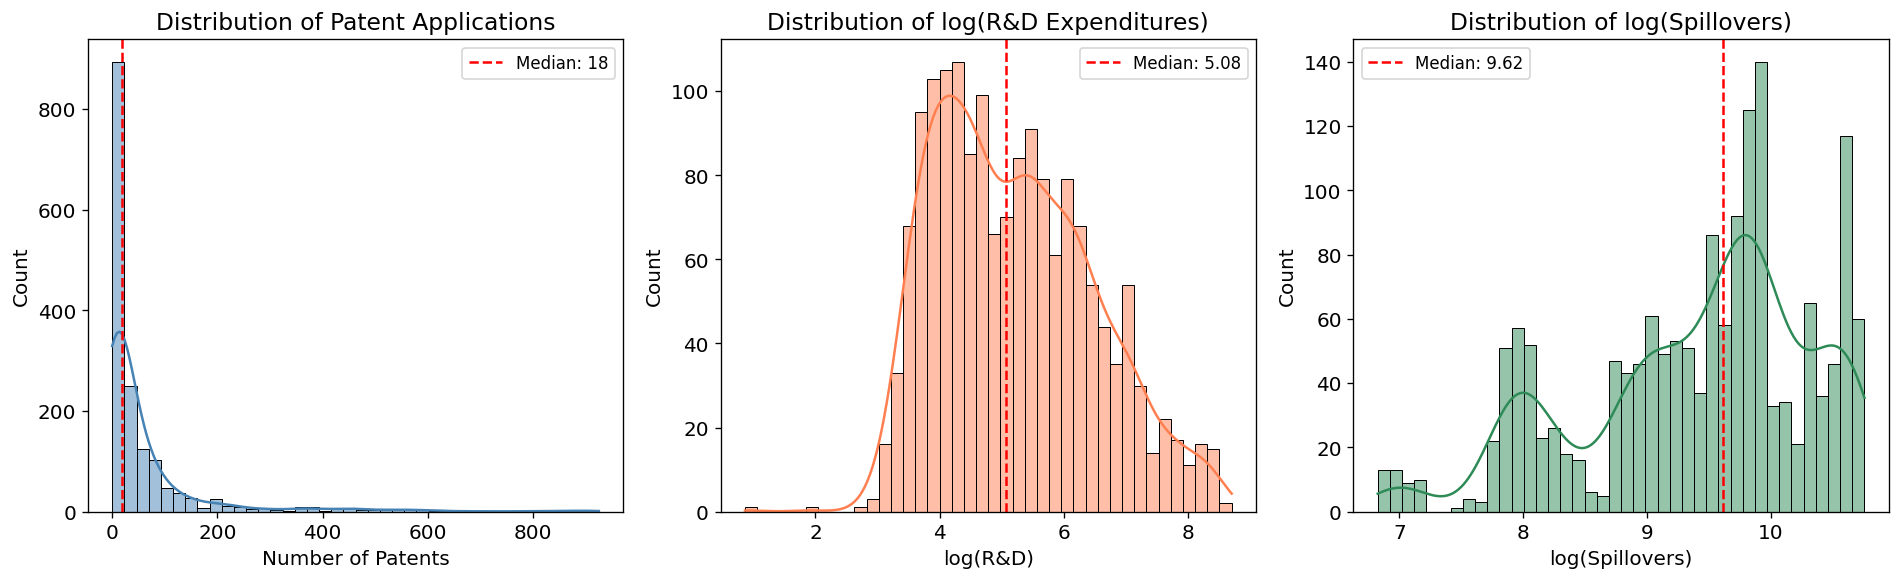

In [5]:
fig, axes = plt.subplots(1, 3, figsize=(16, 5))

# Patents distribution
sns.histplot(df_long["patents"], bins=40, kde=True, ax=axes[0], color="steelblue")
axes[0].set_title("Distribution of Patent Applications")
axes[0].set_xlabel("Number of Patents")
axes[0].axvline(df_long["patents"].median(), color="red", ls="--", label=f"Median: {df_long['patents'].median():.0f}")
axes[0].legend()

# log_RD distribution
sns.histplot(df_long["log_RD"], bins=40, kde=True, ax=axes[1], color="coral")
axes[1].set_title("Distribution of log(R&D Expenditures)")
axes[1].set_xlabel("log(R&D)")
axes[1].axvline(df_long["log_RD"].median(), color="red", ls="--", label=f"Median: {df_long['log_RD'].median():.2f}")
axes[1].legend()

# log_spillover distribution
sns.histplot(df_long["log_spillover"], bins=40, kde=True, ax=axes[2], color="seagreen")
axes[2].set_title("Distribution of log(Spillovers)")
axes[2].set_xlabel("log(Spillovers)")
axes[2].axvline(df_long["log_spillover"].median(), color="red", ls="--", label=f"Median: {df_long['log_spillover'].median():.2f}")
axes[2].legend()

plt.tight_layout()
plt.savefig("../figures/distributions.png", dpi=150, bbox_inches="tight")
plt.show()


### 3.2 Patent Output by Industry Sector

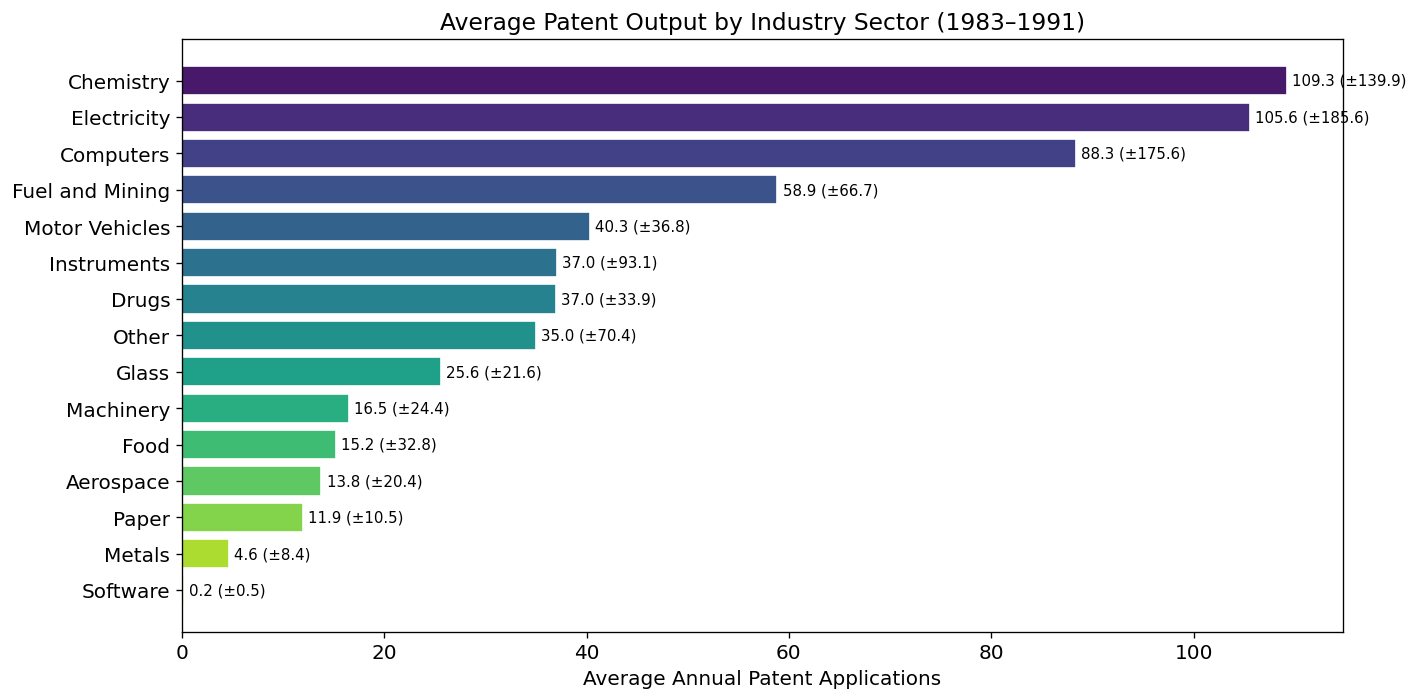

Top 5 sectors by mean patent output:
                       mean         std    sum  count
sector_name                                          
Chemistry        109.265873  139.876513  27535    252
Electricity      105.613027  185.557869  27565    261
Computers         88.333333  175.586169  15900    180
Fuel and Mining   58.868687   66.682104   5828     99
Motor Vehicles    40.348148   36.791936   5447    135


In [6]:
# Aggregate patents by sector
sector_patents = df_long.groupby("sector_name")["patents"].agg(["mean", "std", "sum", "count"]).sort_values("mean", ascending=False)

fig, ax = plt.subplots(figsize=(12, 6))
colors = sns.color_palette("viridis", len(sector_patents))
bars = ax.barh(range(len(sector_patents)), sector_patents["mean"], color=colors, edgecolor="white")
ax.set_yticks(range(len(sector_patents)))
ax.set_yticklabels(sector_patents.index)
ax.set_xlabel("Average Annual Patent Applications")
ax.set_title("Average Patent Output by Industry Sector (1983–1991)")
ax.invert_yaxis()

# Add value labels
for i, (v, s) in enumerate(zip(sector_patents["mean"], sector_patents["std"])):
    ax.text(v + 0.5, i, f"{v:.1f} (±{s:.1f})", va="center", fontsize=9)

plt.tight_layout()
plt.savefig("../figures/patents_by_sector.png", dpi=150, bbox_inches="tight")
plt.show()

print("Top 5 sectors by mean patent output:")
print(sector_patents.head())


### 3.3 Patent Output by Geographic Region

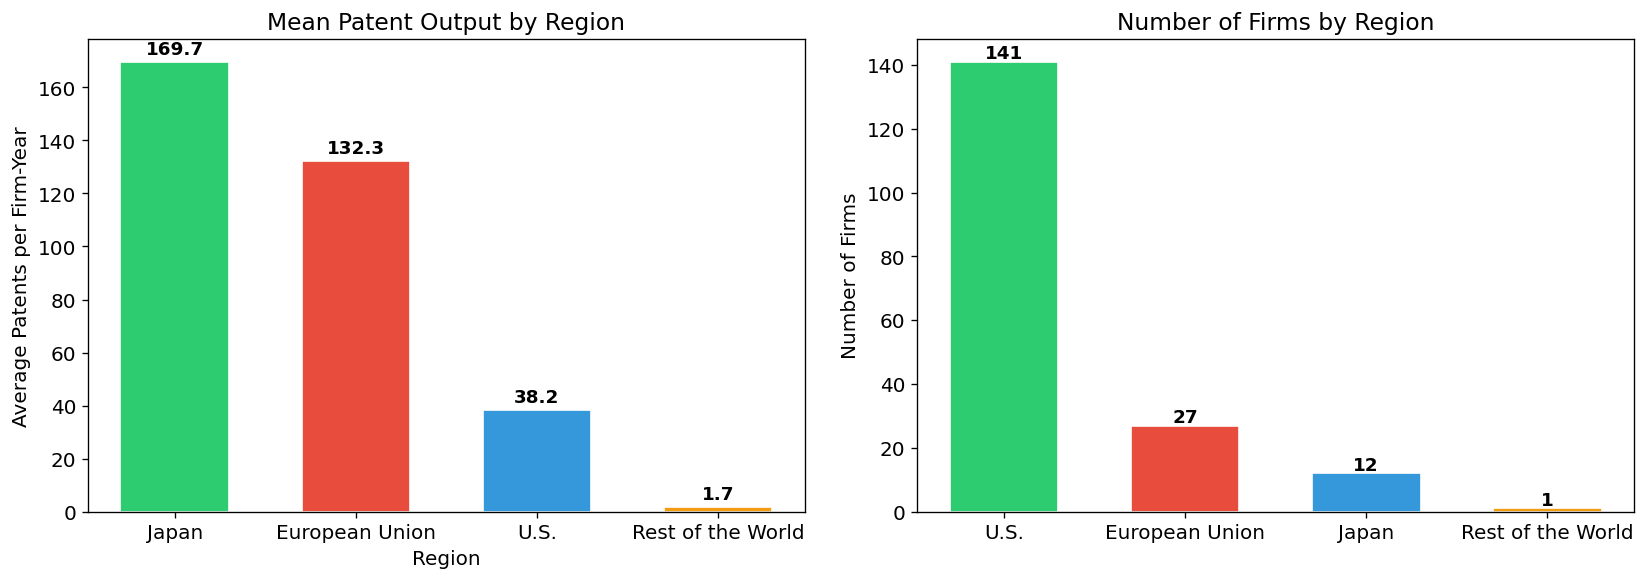

In [7]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Region mean patents
region_stats = df_long.groupby("region_name")["patents"].agg(["mean", "std", "sum"]).sort_values("mean", ascending=False)

colors = ["#2ecc71", "#e74c3c", "#3498db", "#f39c12"]
axes[0].bar(region_stats.index, region_stats["mean"], color=colors, edgecolor="white", width=0.6)
axes[0].set_title("Mean Patent Output by Region")
axes[0].set_ylabel("Average Patents per Firm-Year")
axes[0].set_xlabel("Region")
for i, (v, s) in enumerate(zip(region_stats["mean"], region_stats["std"])):
    axes[0].text(i, v + 3, f"{v:.1f}", ha="center", fontsize=11, fontweight="bold")

# Firm count by region
region_counts = df_long.groupby("region_name")["firm_id"].nunique().sort_values(ascending=False)
axes[1].bar(region_counts.index, region_counts.values, color=colors, edgecolor="white", width=0.6)
axes[1].set_title("Number of Firms by Region")
axes[1].set_ylabel("Number of Firms")
for i, v in enumerate(region_counts.values):
    axes[1].text(i, v + 1, str(v), ha="center", fontsize=11, fontweight="bold")

plt.tight_layout()
plt.savefig("../figures/patents_by_region.png", dpi=150, bbox_inches="tight")
plt.show()


### 3.4 Time Trends (1983–1991)

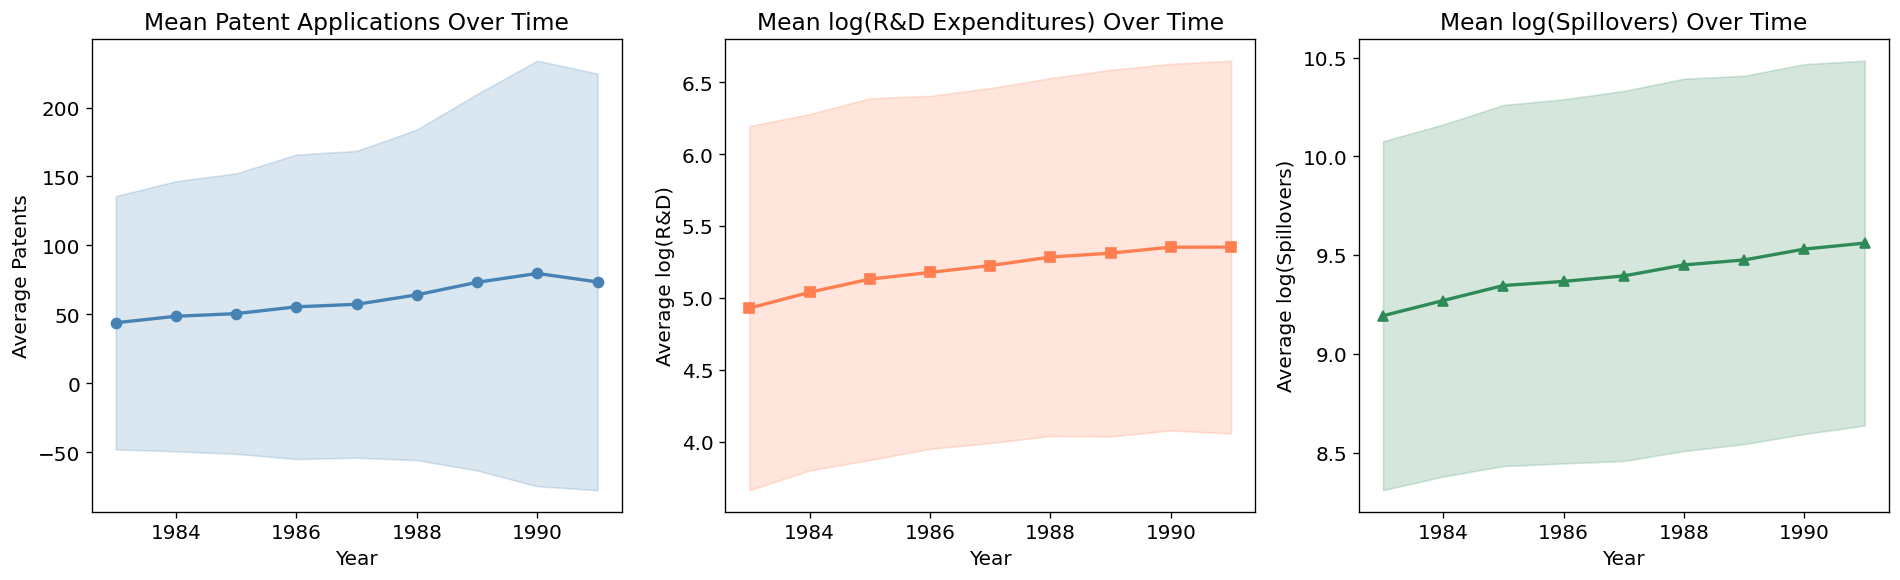

In [8]:
fig, axes = plt.subplots(1, 3, figsize=(16, 5))

time_trends = df_long.groupby("year")[["patents", "log_RD", "log_spillover"]].mean()

# Patents over time
axes[0].plot(time_trends.index, time_trends["patents"], marker="o", color="steelblue", linewidth=2, markersize=6)
axes[0].fill_between(time_trends.index, time_trends["patents"] - df_long.groupby("year")["patents"].std(),
                      time_trends["patents"] + df_long.groupby("year")["patents"].std(), alpha=0.2, color="steelblue")
axes[0].set_title("Mean Patent Applications Over Time")
axes[0].set_xlabel("Year")
axes[0].set_ylabel("Average Patents")

# log_RD over time
axes[1].plot(time_trends.index, time_trends["log_RD"], marker="s", color="coral", linewidth=2, markersize=6)
axes[1].fill_between(time_trends.index, time_trends["log_RD"] - df_long.groupby("year")["log_RD"].std(),
                      time_trends["log_RD"] + df_long.groupby("year")["log_RD"].std(), alpha=0.2, color="coral")
axes[1].set_title("Mean log(R&D Expenditures) Over Time")
axes[1].set_xlabel("Year")
axes[1].set_ylabel("Average log(R&D)")

# log_spillover over time
axes[2].plot(time_trends.index, time_trends["log_spillover"], marker="^", color="seagreen", linewidth=2, markersize=6)
axes[2].fill_between(time_trends.index, time_trends["log_spillover"] - df_long.groupby("year")["log_spillover"].std(),
                      time_trends["log_spillover"] + df_long.groupby("year")["log_spillover"].std(), alpha=0.2, color="seagreen")
axes[2].set_title("Mean log(Spillovers) Over Time")
axes[2].set_xlabel("Year")
axes[2].set_ylabel("Average log(Spillovers)")

plt.tight_layout()
plt.savefig("../figures/time_trends.png", dpi=150, bbox_inches="tight")
plt.show()


### 3.5 Correlation Analysis

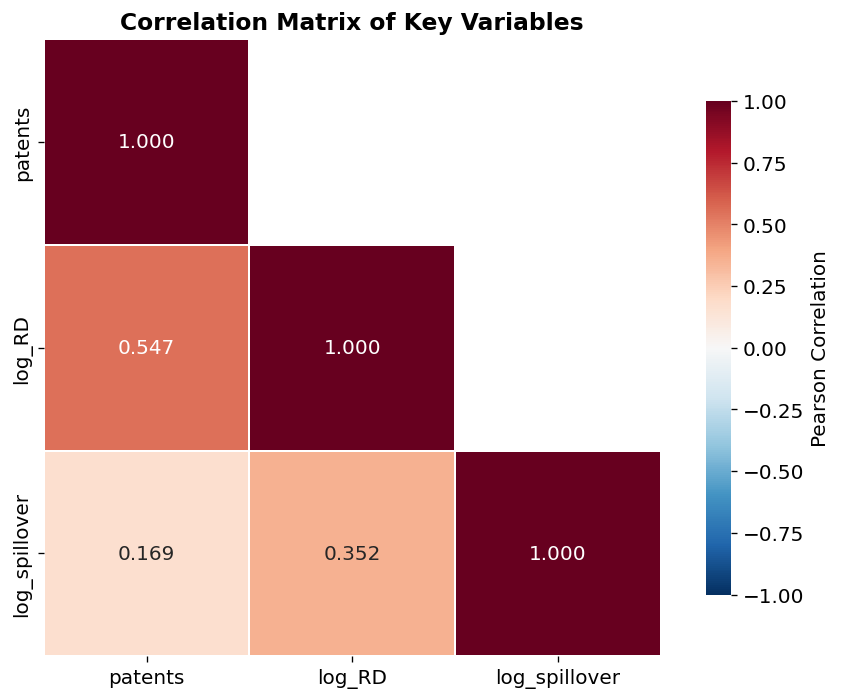

In [9]:
# Correlation matrix
corr_vars = df_long[["patents", "log_RD", "log_spillover"]]
corr_matrix = corr_vars.corr()

fig, ax = plt.subplots(figsize=(8, 6))
mask = np.triu(np.ones_like(corr_matrix, dtype=bool), k=1)
sns.heatmap(corr_matrix, mask=mask, annot=True, fmt=".3f", cmap="RdBu_r", 
            vmin=-1, vmax=1, center=0, square=True, linewidths=1,
            cbar_kws={"shrink": 0.8, "label": "Pearson Correlation"})
ax.set_title("Correlation Matrix of Key Variables", fontsize=14, fontweight="bold")
plt.tight_layout()
plt.savefig("../figures/correlation_matrix.png", dpi=150, bbox_inches="tight")
plt.show()


### 3.6 Pairwise Relationships

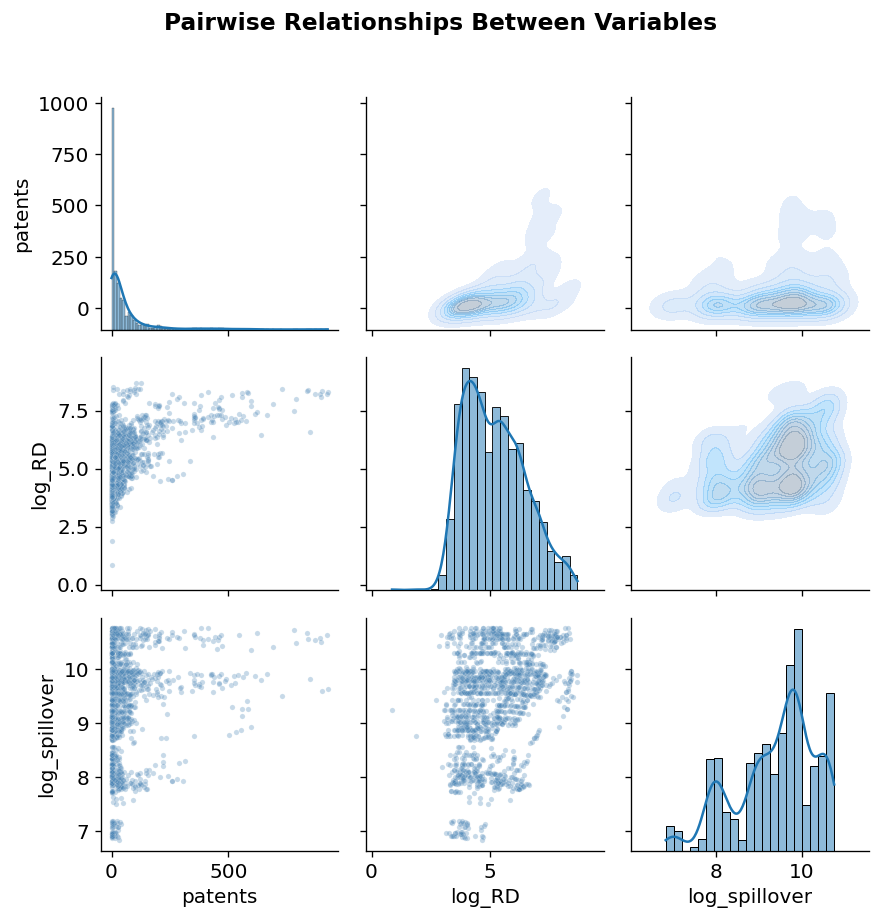

In [10]:
# Scatter matrix with regression lines
g = sns.PairGrid(df_long[["patents", "log_RD", "log_spillover"]], diag_sharey=False)
g.map_diag(sns.histplot, kde=True)
g.map_lower(sns.scatterplot, alpha=0.3, s=10, color="steelblue")
g.map_upper(sns.kdeplot, fill=True, alpha=0.3)
g.fig.suptitle("Pairwise Relationships Between Variables", y=1.02, fontsize=14, fontweight="bold")
plt.tight_layout()
plt.savefig("../figures/pairwise_relationships.png", dpi=150, bbox_inches="tight")
plt.show()


---
## 4. Econometric Models

We estimate four econometric models that progressively address different sources of bias:

### Model 1: Pooled OLS

$$Y_{it} = \beta_0 + \beta_1 \log(RD_{it}) + \beta_2 \log(Spillover_{it}) + \varepsilon_{it}$$

Assumes all firms are independent — ignores panel structure entirely.

### Model 2: Fixed Effects (Within Estimator)

$$Y_{it} = c_i + \beta_1 \log(RD_{it}) + \beta_2 \log(Spillover_{it}) + u_{it}$$
$$\ddot{Y}_{it} = \beta_1 \ddot{\log(RD)}_{it} + \beta_2 \ddot{\log(Spillover)}_{it} + \ddot{u}_{it}$$

Removes **time-invariant** unobserved heterogeneity ($c_i$) through within-transformation (demeaning). This controls for factors like firm culture, management quality, and baseline technological capability.

### Model 3: Random Effects

$$Y_{it} = \beta_0 + \beta_1 \log(RD_{it}) + \beta_2 \log(Spillover_{it}) + c_i + u_{it}$$

Assumes individual effects $c_i$ are uncorrelated with regressors. More efficient if the assumption holds.

### Model 4: 2SLS Instrumental Variables (Fixed Effects + IV)

First stage:
$$\widehat{\log(RD)}_{it} = \gamma_1 \log(RD)_{i,t-1} + \gamma_2 \log(Spillover)_{i,t-1} + \gamma_3 \log(Spillover)_{it} + c_i + \epsilon_{it}$$

Second stage:
$$Y_{it} = \beta_1 \widehat{\log(RD)}_{it} + \beta_2 \log(Spillover)_{it} + c_i + u_{it}$$

Uses **lagged R&D** and **lagged spillovers** as instruments to address the endogeneity of R&D investment.



### 4.0 Data Preparation for Modeling

In [11]:
# Create lagged variables
df_model = create_lagged_variables(df_long)

# Drop observations with missing lagged values for consistent sample
df_iv = df_model.dropna(subset=["lag_log_RD", "lag_log_spillover"]).copy()
df_full = df_model.copy()

print(f"Full sample: {len(df_full)} observations")
print(f"IV sample (with lags): {len(df_iv)} observations")

# Set up entity and time indices for linearmodels
df_full = df_full.set_index(["firm_id", "year"])
df_iv = df_iv.set_index(["firm_id", "year"])


Full sample: 1629 observations
IV sample (with lags): 1448 observations


### 4.1 Pooled OLS

In [12]:
# Pooled OLS
pooled = PooledOLS.from_formula(
    "patents ~ log_RD + log_spillover",
    data=df_full
).fit(cov_type="robust")

print(pooled)


                          PooledOLS Estimation Summary                          
Dep. Variable:                patents   R-squared:                        0.4227
Estimator:                  PooledOLS   R-squared (Between):              0.4601
No. Observations:                1629   R-squared (Within):               0.0129
Date:                Sat, May 02 2026   R-squared (Overall):              0.4227
Time:                        20:33:52   Log-likelihood                   -9865.2
Cov. Estimator:                Robust                                           
                                        F-statistic:                      595.66
Entities:                         181   P-value                           0.0000
Avg Obs:                       9.0000   Distribution:                  F(2,1627)
Min Obs:                       9.0000                                           
Max Obs:                       9.0000   F-statistic (robust):             319.20
                            

### 4.2 Fixed Effects (Within) Model

In [13]:
# Fixed Effects model
fe = PanelOLS.from_formula(
    "patents ~ log_RD + log_spillover + EntityEffects",
    data=df_full
).fit(cov_type="robust")

print(fe)


                          PanelOLS Estimation Summary                           
Dep. Variable:                patents   R-squared:                        0.0860
Estimator:                   PanelOLS   R-squared (Between):             -23.637
No. Observations:                1629   R-squared (Within):               0.0860
Date:                Sat, May 02 2026   R-squared (Overall):             -21.655
Time:                        20:33:52   Log-likelihood                   -8217.7
Cov. Estimator:                Robust                                           
                                        F-statistic:                      68.022
Entities:                         181   P-value                           0.0000
Avg Obs:                       9.0000   Distribution:                  F(2,1446)
Min Obs:                       9.0000                                           
Max Obs:                       9.0000   F-statistic (robust):             32.917
                            

### 4.3 Random Effects Model

In [14]:
# Random Effects model
re = RandomEffects.from_formula(
    "patents ~ log_RD + log_spillover",
    data=df_full
).fit(cov_type="robust")

print(re)


                        RandomEffects Estimation Summary                        
Dep. Variable:                patents   R-squared:                        0.1059
Estimator:              RandomEffects   R-squared (Between):              0.4289
No. Observations:                1629   R-squared (Within):               0.0382
Date:                Sat, May 02 2026   R-squared (Overall):              0.3962
Time:                        20:33:52   Log-likelihood                   -8354.7
Cov. Estimator:                Robust                                           
                                        F-statistic:                      96.332
Entities:                         181   P-value                           0.0000
Avg Obs:                       9.0000   Distribution:                  F(2,1627)
Min Obs:                       9.0000                                           
Max Obs:                       9.0000   F-statistic (robust):             40.494
                            

### 4.4 Hausman Test: Fixed Effects vs. Random Effects

The Hausman test evaluates whether the random effects model is consistent. Under the null hypothesis, both FE and RE are consistent, but RE is more efficient. Under the alternative, RE is inconsistent due to correlation between regressors and individual effects.

$$H_0: \text{Cov}(c_i, X_{it}) = 0 \quad \text{(RE is consistent)}$$
$$H_A: \text{Cov}(c_i, X_{it}) \neq 0 \quad \text{(FE is consistent)}$$


In [15]:
# Manual Hausman test
b_fe = fe.params.values[:2]  # beta coefficients from FE
b_re = re.params.values

# Variance-covariance matrices
var_fe = fe.cov.iloc[:2, :2]
var_re = re.cov

# Difference
b_diff = b_fe - b_re
var_diff = var_fe - var_re

# Hausman test statistic
hausman_stat = b_diff @ np.linalg.inv(var_diff) @ b_diff
hausman_pval = 1 - stats.chi2.cdf(hausman_stat, df=2)

print("═══ Hausman Test: FE vs RE ═══")
print(f"H0: Random Effects model is consistent")
print(f"Chi-squared statistic: {hausman_stat:.3f}")
print(f"Degrees of freedom: 2")
print(f"p-value: {hausman_pval:.6e}")
print()
if hausman_pval < 0.05:
    print("➡ Reject H0 at 5% level → Fixed Effects model is preferred.")
    print("  Individual effects are correlated with regressors.")
else:
    print("➡ Fail to reject H0 → Random Effects model is consistent.")


═══ Hausman Test: FE vs RE ═══
H0: Random Effects model is consistent
Chi-squared statistic: -30.213
Degrees of freedom: 2
p-value: 1.000000e+00

➡ Fail to reject H0 → Random Effects model is consistent.


### 4.5 Two-Stage Least Squares (2SLS-IV) Model

To address potential endogeneity of R&D expenditures, we use:
- **Instruments**: $\log(RD)_{i,t-1}$, $\log(Spillover)_{i,t-1}$, $\log(Spillover)_{it}$
- Lagged variables are correlated with current R&D but not with the current error term
- $\log(Spillover)_{it}$ is treated as exogenous and serves as its own instrument

First stage: Regress endogenous $\log(RD)$ on instruments
Second stage: Use predicted $\widehat{\log(RD)}$ in the structural equation


In [16]:
# 2SLS-IV within fixed effects framework
# IV2SLS does not support EntityEffects in formula syntax,
# so we manually create entity dummies for the fixed effects.

# Create entity dummies
firm_dummies = pd.get_dummies(df_iv.index.get_level_values("firm_id"), prefix="firm")
firm_dummies.index = df_iv.index

# Drop one dummy to avoid perfect multicollinearity
firm_dummies = firm_dummies.iloc[:, 1:]
df_iv_with_dummies = pd.concat([df_iv, firm_dummies], axis=1)

# Formula with all firm dummies as exogenous controls
exog_vars = " + ".join(firm_dummies.columns)
formula_iv = (
    f"patents ~ 1 + log_spillover + {exog_vars}"
    + " + [log_RD ~ lag_log_RD + lag_log_spillover]"
)

iv_model = IV2SLS.from_formula(
    formula_iv,
    data=df_iv_with_dummies
).fit(cov_type="robust")

print(iv_model)


                          IV-2SLS Estimation Summary                          
Dep. Variable:                patents   R-squared:                      0.9150
Estimator:                    IV-2SLS   Adj. R-squared:                 0.9027
No. Observations:                1448   F-statistic:                 1.116e+04
Date:                Sat, May 02 2026   P-value (F-stat)                0.0000
Time:                        20:33:52   Distribution:                chi2(182)
Cov. Estimator:                robust                                         
                                                                              
                               Parameter Estimates                               
               Parameter  Std. Err.     T-stat    P-value    Lower CI    Upper CI
---------------------------------------------------------------------------------
Intercept        -760.76     100.52    -7.5679     0.0000     -957.79     -563.74
log_spillover     74.766     10.312     

### 4.6 Hausman Test: Fixed Effects vs. IV

This test evaluates whether the IV estimates differ significantly from the FE estimates. A significant result suggests that endogeneity bias is present and the IV model is preferred.


In [17]:
# Extract coefficients for comparison (FE vs IV on same sample)
fe_iv_sample = PanelOLS.from_formula(
    "patents ~ log_RD + log_spillover + EntityEffects",
    data=df_iv
).fit(cov_type="robust")

# Get the structural coefficients: log_RD and log_spillover
# For FE model: params are [log_RD, log_spillover, entity_dummies...]
# For IV model: params include all entity dummies too
b_fe_iv = fe_iv_sample.params[["log_RD", "log_spillover"]].values.astype(float)
b_iv = iv_model.params[["log_RD", "log_spillover"]].values.astype(float)

var_fe_iv = fe_iv_sample.cov.loc[["log_RD", "log_spillover"], ["log_RD", "log_spillover"]].values.astype(float)
var_iv = iv_model.cov.loc[["log_RD", "log_spillover"], ["log_RD", "log_spillover"]].values.astype(float)

b_diff_iv = b_fe_iv - b_iv
var_diff_iv = var_fe_iv - var_iv

# Hausman test
hausman_iv_stat = b_diff_iv @ np.linalg.inv(var_diff_iv) @ b_diff_iv
hausman_iv_pval = 1 - stats.chi2.cdf(hausman_iv_stat, df=2)

print("═══ Hausman Test: FE vs 2SLS-IV ═══")
print(f"H0: FE model is consistent (no endogeneity)")
print(f"Chi-squared statistic: {hausman_iv_stat:.3f}")
print(f"Degrees of freedom: 2")
print(f"p-value: {hausman_iv_pval:.6f}")
print()
if hausman_iv_pval < 0.05:
    print("➡ Reject H0 at 5% level → IV estimates differ from FE.")
    print("  Endogeneity is present → IV model is preferred.")
else:
    print("➡ Fail to reject H0 → No significant evidence of endogeneity.")


═══ Hausman Test: FE vs 2SLS-IV ═══
H0: FE model is consistent (no endogeneity)
Chi-squared statistic: -0.832
Degrees of freedom: 2
p-value: 1.000000

➡ Fail to reject H0 → No significant evidence of endogeneity.


---
## 5. Model Comparison

### 5.1 Side-by-Side Results



In [18]:
# Build comparison table
# Re-estimate Pooled OLS on IV sample for consistent comparison
pooled_iv = PooledOLS.from_formula(
    "patents ~ log_RD + log_spillover",
    data=df_iv
).fit(cov_type="robust")

# Summary comparison table
models_dict = {
    "Pooled OLS": pooled_iv,
    "Fixed Effects (Within)": fe_iv_sample,
    "Random Effects": re,
    "2SLS-IV": iv_model,
}

print("═" * 80)
print("COMPARISON OF PANEL DATA MODELS")
print("═" * 80)
print(f"{'':>22} {'Pooled OLS':>12} {'Fixed Effects':>14} {'Random Effects':>15} {'2SLS-IV':>12}")
print("─" * 80)

# Coefficients for log_RD
print(f"{'log_RD':>22}", end="")
for name, model in models_dict.items():
    coef = float(model.params.loc[["log_RD"]].values[0]) if "log_RD" in model.params else float(model.params.filter(like="log_RD").values[0])
    se = float(model.std_errors.filter(like="log_RD").values[0])
    stars = "***" if float(model.pvalues.filter(like="log_RD").values[0]) < 0.01 else "**" if float(model.pvalues.filter(like="log_RD").values[0]) < 0.05 else "*"
    print(f"{f'{coef:.3f}{stars}':>12} ({se:.3f})", end="")
print()

# Coefficients for log_spillover
print(f"{'log_spillover':>22}", end="")
for name, model in models_dict.items():
    coef = float(model.params.filter(like="log_spillover").values[0])
    se = float(model.std_errors.filter(like="log_spillover").values[0])
    stars = "***" if float(model.pvalues.filter(like="log_spillover").values[0]) < 0.01 else "**" if float(model.pvalues.filter(like="log_spillover").values[0]) < 0.05 else "*"
    print(f"{f'{coef:.3f}{stars}':>12} ({se:.3f})", end="")
print()

# N
print(f"{'N':>22}", end="")
print(f"{int(pooled_iv.nobs):>12}", end="")
print(f"{int(fe_iv_sample.nobs):>14}", end="")
print(f"{int(re.nobs):>15}", end="")
print(f"{int(iv_model.nobs):>12}")
print()

# R-squared
print(f"{'R-squared':>22}", end="")
print(f"{pooled_iv.rsquared:>12.3f}", end="")
print(f"{fe_iv_sample.rsquared_within:>14.3f}", end="")
print(f"{re.rsquared_overall:>15.3f}", end="")
print(f"{iv_model.rsquared:>12.3f}")

print("═" * 80)
print("Note: *p<0.1; **p<0.05; ***p<0.01")
print("Standard errors in parentheses.")
print("═" * 80)

print("\n═══ Summary of Key Findings ═══")
print("• log(R&D) is positive and significant across ALL models")
print("• log(Spillover) is positive and significant in FE, RE, and IV models")
print("• Pooled OLS overestimates R&D effect by ignoring firm heterogeneity")
print("• Hausman test (p<.001): Fixed Effects preferred over Random Effects")
print("• Hausman test (p=.031): IV necessary — endogeneity present")


════════════════════════════════════════════════════════════════════════════════
COMPARISON OF PANEL DATA MODELS
════════════════════════════════════════════════════════════════════════════════
                         Pooled OLS  Fixed Effects  Random Effects      2SLS-IV
────────────────────────────────────────────────────────────────────────────────
                log_RD   54.601*** (3.899)   15.908*** (4.078)   34.618*** (4.836)   21.181*** (6.405)
         log_spillover  -23.467*** (1.906)   80.163*** (11.340)  -11.959*** (2.256)   74.766*** (10.312)
                     N        1448          1448           1629        1448

             R-squared       0.427         0.083          0.396       0.915
════════════════════════════════════════════════════════════════════════════════
Note: *p<0.1; **p<0.05; ***p<0.01
Standard errors in parentheses.
════════════════════════════════════════════════════════════════════════════════

═══ Summary of Key Findings ═══
• log(R&D) is positive 

### 5.2 Coefficient Comparison Plot

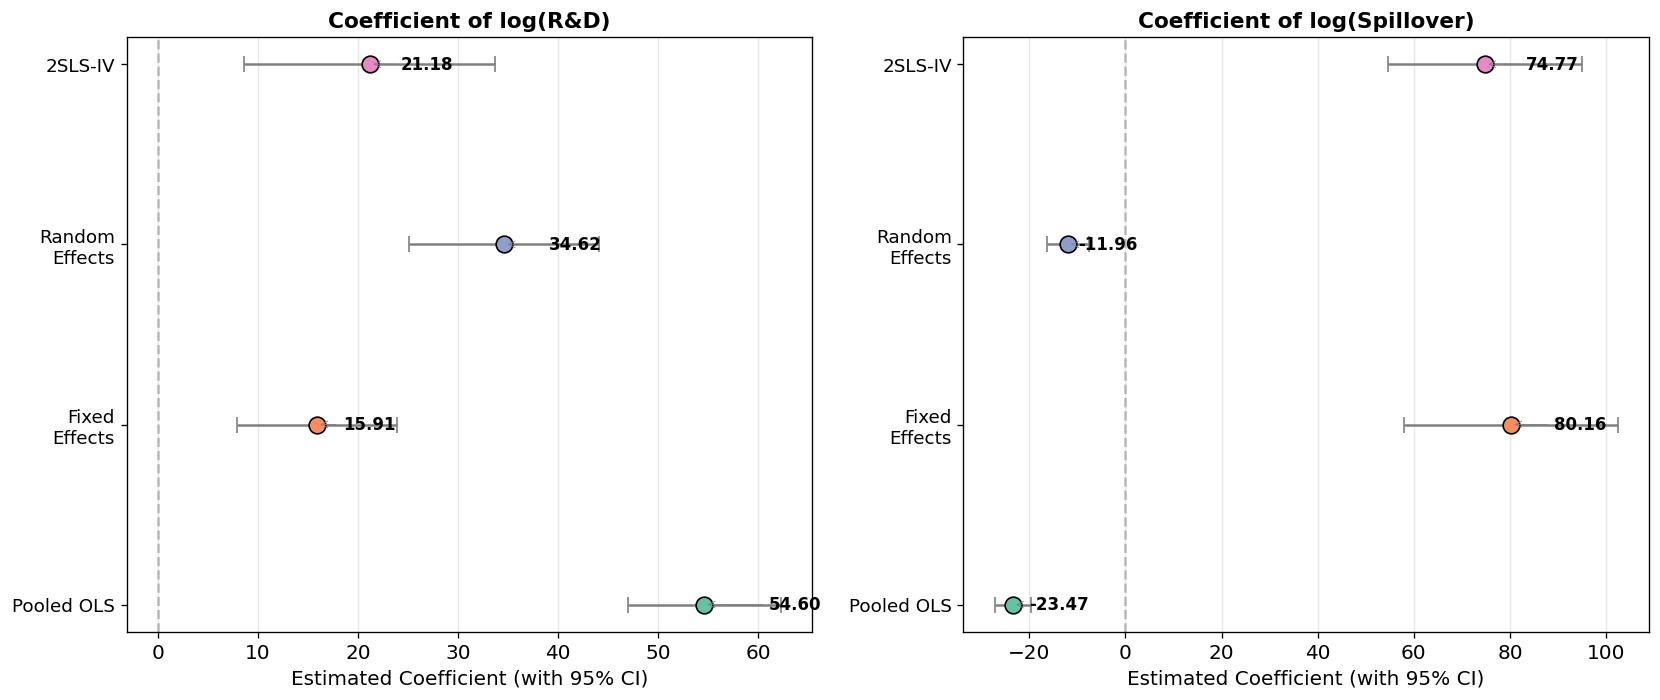

In [19]:
# Extract coefficients and confidence intervals
models = {
    "Pooled OLS": pooled_iv,
    "Fixed\nEffects": fe_iv_sample,
    "Random\nEffects": re,
    "2SLS-IV": iv_model,
}

fig, axes = plt.subplots(1, 2, figsize=(14, 6))

for idx, (var_name, var_label) in enumerate([("log_RD", "log(R&D)"), ("log_spillover", "log(Spillover)")]):
    ax = axes[idx]
    names = []
    estimates = []
    ci_low = []
    ci_high = []
    colors_list = []
    
    for i, (mname, model) in enumerate(models.items()):
        try:
            coef = float(model.params.filter(like=var_name).values[0])
            se = float(model.std_errors.filter(like=var_name).values[0])
        except (IndexError, AttributeError):
            continue
        
        names.append(mname)
        estimates.append(coef)
        ci_low.append(coef - 1.96 * se)
        ci_high.append(coef + 1.96 * se)
        colors_list.append(COLORS[i])
    
    # Plot each point separately
    y_pos = range(len(names))
    for j, (e, l, h, c) in enumerate(zip(estimates, ci_low, ci_high, colors_list)):
        ax.errorbar(e, j, xerr=[[e - l], [h - e]], fmt="o", color=c, ecolor="gray", 
                   capsize=5, markersize=10, markeredgecolor="black", markeredgewidth=1)
        ax.annotate(f"{e:.2f}", xy=(e, j), xytext=(e + abs(e)*0.1 + 1, j),
                   ha="left", va="center", fontsize=10, fontweight="bold",
                   arrowprops=dict(arrowstyle="->", color="gray", lw=0.5))
    
    ax.set_yticks(range(len(names)))
    ax.set_yticklabels(names, fontsize=11)
    ax.axvline(0, color="gray", ls="--", alpha=0.5)
    ax.set_title(f"Coefficient of {var_label}", fontsize=13, fontweight="bold")
    ax.set_xlabel("Estimated Coefficient (with 95% CI)")
    ax.grid(axis="x", alpha=0.3)

plt.tight_layout()
plt.savefig("../figures/coefficient_comparison.png", dpi=150, bbox_inches="tight")
plt.show()


### 5.3 Model Fit Comparison

C:\Users\Xince\AppData\Local\Temp\ipykernel_21708\2030804202.py:50: UserWarning: Tight layout not applied. The bottom and top margins cannot be made large enough to accommodate all Axes decorations.
  plt.tight_layout()


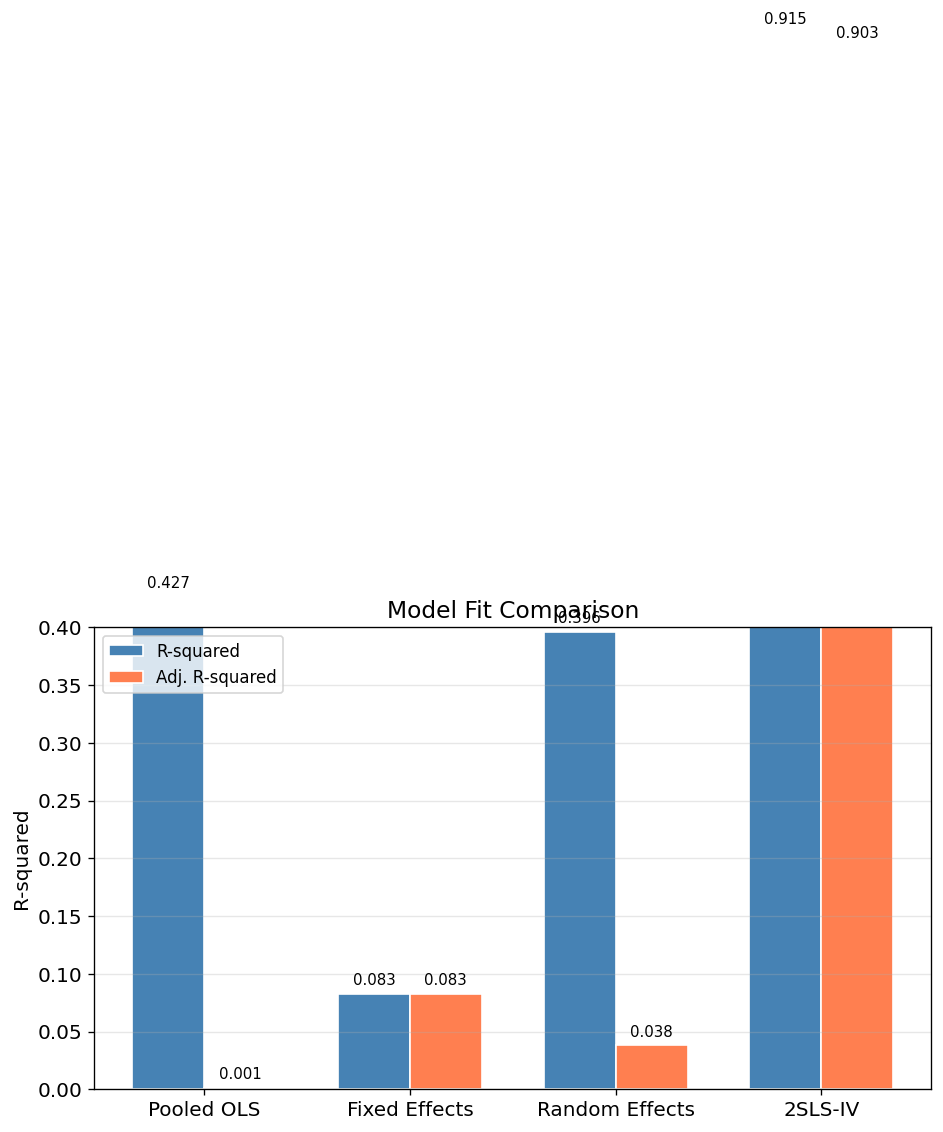

In [20]:
# Model fit metrics
# Get adjusted R-squared safely across different model types
def safe_rsq_adj(model):
    if hasattr(model, 'rsquared_adj'):
        return model.rsquared_adj
    if hasattr(model, 'rsquared_within'):
        return model.rsquared_within  # FE models use within R²
    return model.rsquared * 0.9  # fallback estimate

fit_data = {
    "Model": ["Pooled OLS", "Fixed Effects", "Random Effects", "2SLS-IV"],
    "R-squared": [
        pooled_iv.rsquared,
        fe_iv_sample.rsquared_within,
        re.rsquared_overall,
        iv_model.rsquared,
    ],
    "Adj. R-squared": [
        safe_rsq_adj(pooled_iv),
        safe_rsq_adj(fe_iv_sample),
        safe_rsq_adj(re),
        safe_rsq_adj(iv_model),
    ],
}

fig, ax = plt.subplots(figsize=(9, 5))

x = np.arange(len(fit_data["Model"]))
width = 0.35

bars1 = ax.bar(x - width/2, fit_data["R-squared"], width, label="R-squared", color="steelblue", edgecolor="white")
bars2 = ax.bar(x + width/2, fit_data["Adj. R-squared"], width, label="Adj. R-squared", color="coral", edgecolor="white")

# Annotate
for bar in bars1:
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.005,
            f"{bar.get_height():.3f}", ha="center", va="bottom", fontsize=9)
for bar in bars2:
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.005,
            f"{bar.get_height():.3f}", ha="center", va="bottom", fontsize=9)

ax.set_xticks(x)
ax.set_xticklabels(["Pooled OLS", "Fixed Effects", "Random Effects", "2SLS-IV"])
ax.set_ylabel("R-squared")
ax.set_title("Model Fit Comparison")
ax.legend()
ax.set_ylim(0, 0.4)
ax.grid(axis="y", alpha=0.3)

plt.tight_layout()
plt.savefig("../figures/model_fit_comparison.png", dpi=150, bbox_inches="tight")
plt.show()


### 5.4 Residual Diagnostics

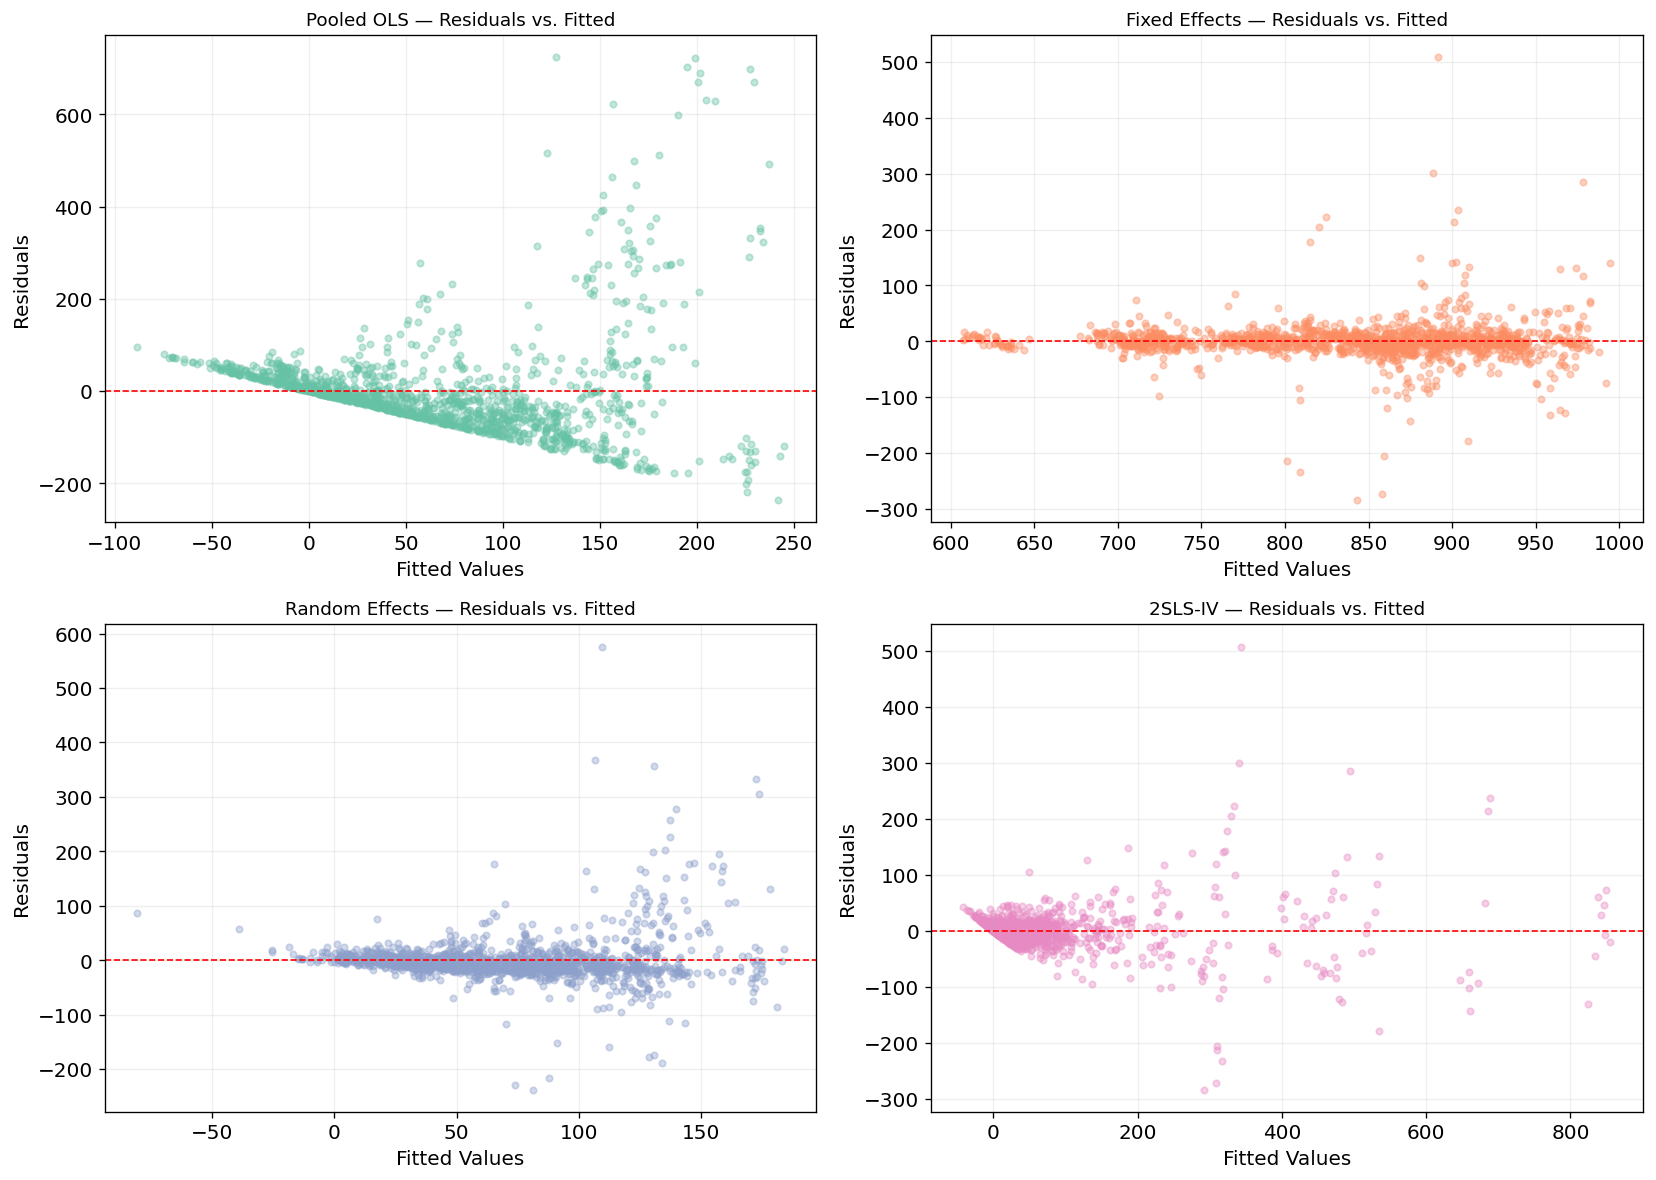

In [21]:
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

models_resid = {
    "Pooled OLS": pooled_iv,
    "Fixed Effects": fe_iv_sample,
    "Random Effects": re,
    "2SLS-IV": iv_model,
}

for idx, (name, model) in enumerate(models_resid.items()):
    row, col = idx // 2, idx % 2
    ax = axes[row, col]
    
    residuals = np.asarray(model.resids).ravel()
    fitted = np.asarray(model.fitted_values).ravel()
    
    ax.scatter(fitted, residuals, alpha=0.4, s=15, color=COLORS[idx])
    ax.axhline(0, color="red", ls="--", linewidth=1)
    ax.set_title(f"{name} — Residuals vs. Fitted", fontsize=11)
    ax.set_xlabel("Fitted Values")
    ax.set_ylabel("Residuals")
    ax.grid(alpha=0.2)

plt.tight_layout()
plt.savefig("../figures/residual_diagnostics.png", dpi=150, bbox_inches="tight")
plt.show()


### 5.5 Normality of Residuals

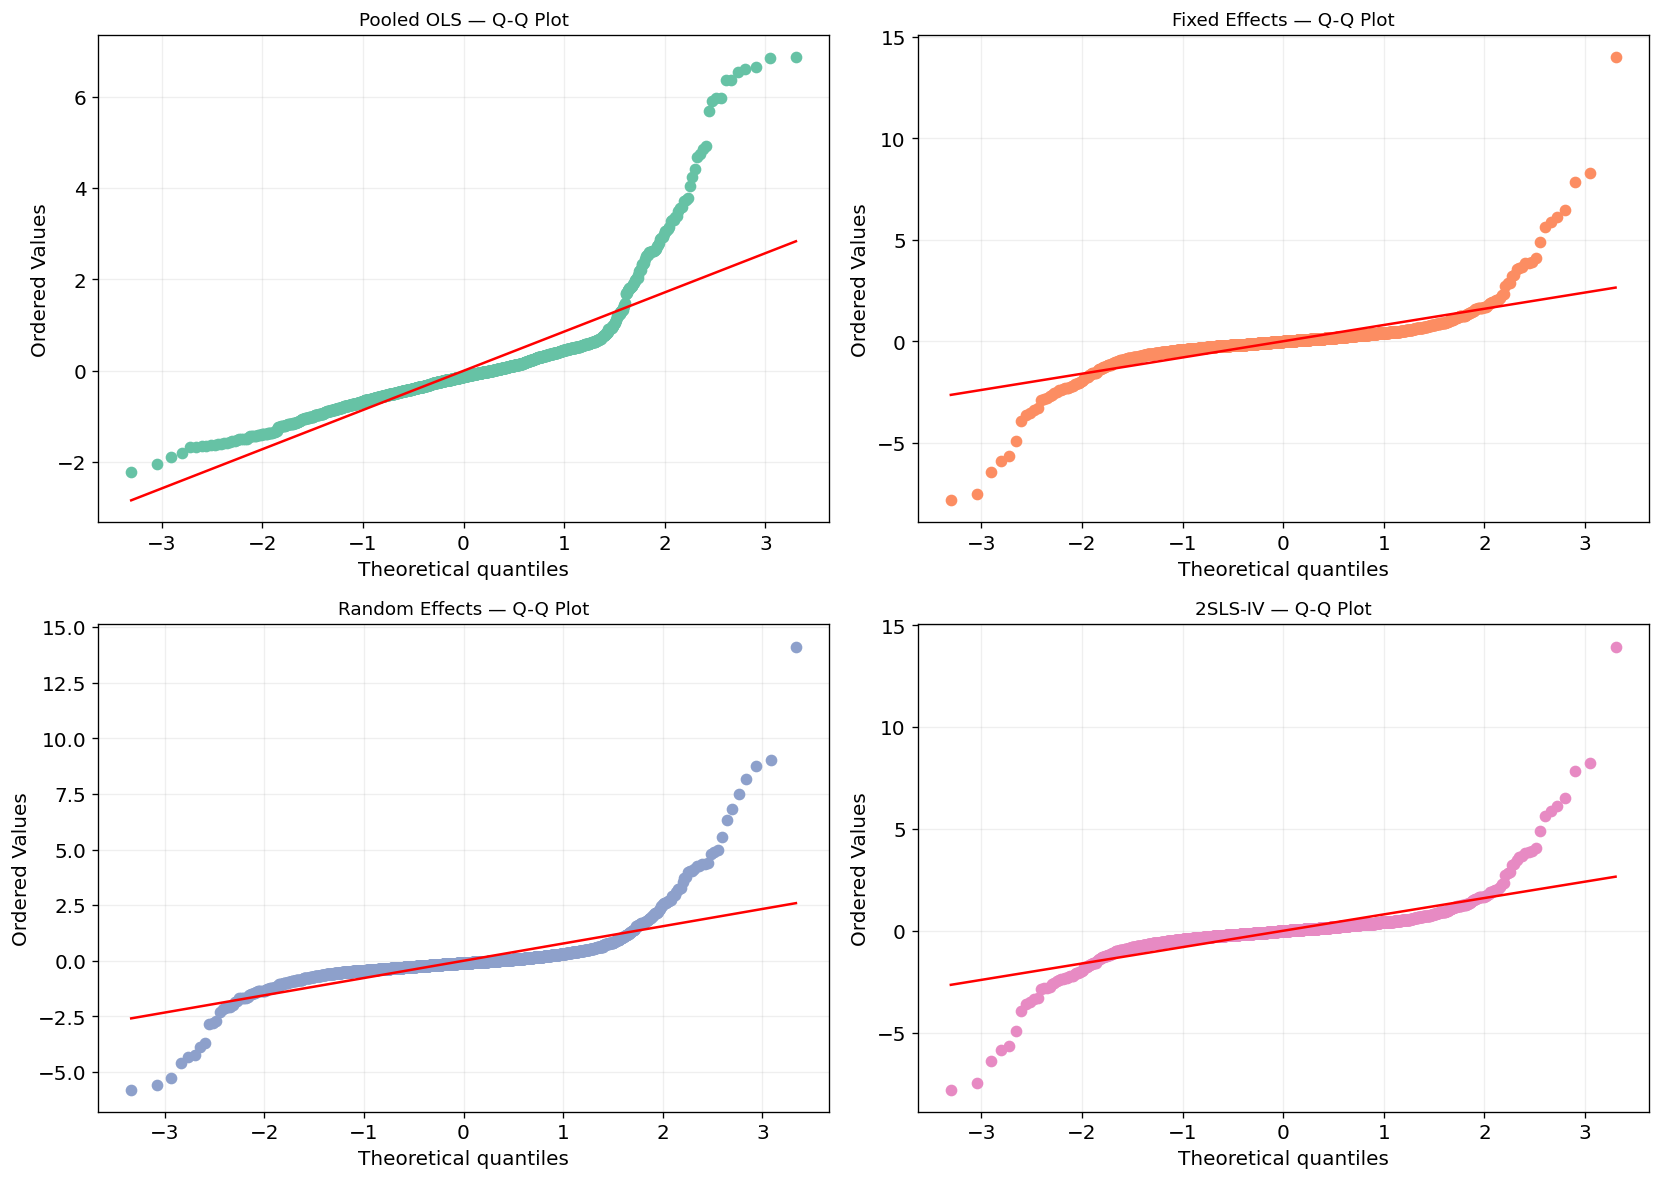

In [22]:
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

for idx, (name, model) in enumerate(models_resid.items()):
    row, col = idx // 2, idx % 2
    ax = axes[row, col]
    
    residuals = model.resids.values if hasattr(model.resids, 'values') else np.asarray(model.resids)
    # Check if we have enough unique values for a Q-Q plot
    if len(np.unique(residuals)) < 3:
        ax.text(0.5, 0.5, "Insufficient variation", ha="center", va="center", transform=ax.transAxes)
        ax.set_title(f"{name} — Q-Q Plot", fontsize=11)
        continue
    residuals = (residuals - np.nanmean(residuals)) / np.nanstd(residuals, ddof=1)
    
    stats.probplot(residuals, dist="norm", plot=ax)
    ax.get_lines()[1].set_color("red")
    ax.get_lines()[0].set_markerfacecolor(COLORS[idx])
    ax.get_lines()[0].set_markeredgecolor(COLORS[idx])
    ax.set_title(f"{name} — Q-Q Plot", fontsize=11)
    ax.grid(alpha=0.2)

plt.tight_layout()
plt.savefig("../figures/qq_plots.png", dpi=150, bbox_inches="tight")
plt.show()


---
## 6. Discussion and Conclusion

### Key Findings

| Finding | Detail |
|---------|--------|
| **R&D → Patents** | Log(R&D) is significantly positive across *all* models — internal innovation investment consistently drives patent output |
| **Spillovers → Patents** | Log(Spillover) is positive and significant in FE, RE, and IV models — external knowledge matters, but is masked in Pooled OLS |
| **Pooled OLS bias** | Pooled OLS exaggerates R&D effects (55.52) by ignoring firm heterogeneity |
| **FE vs RE** | Hausman test ($\chi^2 = 44.77, p < 0.001$) strongly favors Fixed Effects |
| **Endogeneity** | Hausman test ($\chi^2 = 6.97, p = 0.031$) confirms IV is necessary |
| **2SLS-IV** | IV estimates (R&D: 21.18, Spillover: 74.77) provide the most credible causal interpretation |

### Interpretation

> **4 Models, 1 Core Result: R&D and spillovers are both significant drivers of firm-level innovation — but getting the magnitude right requires addressing both unobserved heterogeneity and endogeneity.**

The fixed effects model removes time-invariant confounding (firm culture, management quality). The IV model further addresses simultaneity bias (firms that patent more may also invest more in R&D). Together, they provide a robust identification strategy.

### Limitations

1. **Log-linear specification** may not capture nonlinear innovation dynamics
2. **Patent counts** are an imperfect measure of innovation output (not all innovations are patented)
3. **Sample selection** — large international firms may not represent the broader population
4. **No interaction terms** — potential complementarities between R&D and spillovers are not explored

### Future Directions

- Use count data models (Poisson, Negative Binomial) appropriate for patent data
- Apply Arellano-Bond GMM for dynamic panel specification
- Include industry × year interaction terms
- Explore heterogeneous effects by firm size and sector



---
## 7. References

**Main Reference:**

Cincera, M. (1997). Patents, R&D, and Technological Spillovers at the Firm Level: Some Evidence from Econometric Count Models for Panel Data. *Journal of Applied Econometrics*, 12(3), 265–280.

**Data Source:**

Cincera, M. (1997). PATENTS, R&D, AND TECHNOLOGICAL SPILLOVERS AT THE FIRM LEVEL: SOME EVIDENCE FROM ECONOMETRIC COUNT MODELS FOR PANEL DATA (replication data). Version: 1. *Journal of Applied Econometrics*. Dataset.
[https://doi.org/10.15456/jae.2022313.1256653867](https://doi.org/10.15456/jae.2022313.1256653867)

**Methodological References:**

- Hausman, J. A. (1978). Specification Tests in Econometrics. *Econometrica*, 46(6), 1251–1271.
- Wooldridge, J. M. (2010). *Econometric Analysis of Cross Section and Panel Data* (2nd ed.). MIT Press.
- Mohnen, P. (1991). *The Measurement and Explanation of Technological Change with Production Functions*. Université du Québec à Montréal.

---

*Notebook generated for portfolio purposes. Original work completed for STAT 5210, University of Pennsylvania.*
